In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import seaborn as sns
import os 
warnings.filterwarnings("ignore")

train_data  = "/Users/annalappo/Desktop/GitHub_2/Data-Drift-Challenge/Anna_Lappo/creditcard.csv"
production_data = [f"/Users/annalappo/Desktop/GitHub_2/Data-Drift-Challenge/drift_{i}.csv" for i in range(1, 6)]

train_df = pd.read_csv(train_data)
print(f"Train: {train_df.shape}")

prod_dfs = {}
for fname in production_data:
    try:
        df = pd.read_csv(fname)
        prod_dfs[fname] = df
        print(f"{os.path.splitext(os.path.basename(fname))[0]}: {df.shape}")
    except FileNotFoundError:
        print(f"{os.path.splitext(os.path.basename(fname))[0]}: NOT FOUND — skipping")

if not prod_dfs:
    print("No production files found. Check filenames.")
    exit()

columns_not = {"Class", "day", "Time"}
feature_cols = [c for c in train_df.columns if c not in columns_not]


all_prod_df = pd.concat(prod_dfs.values(), ignore_index=True)


Train: (284807, 31)
drift_1: (15000, 32)
drift_2: (15000, 32)
drift_3: (18000, 32)
drift_4: (15000, 32)
drift_5: (15000, 32)



Plot 1: Summary statistics ...


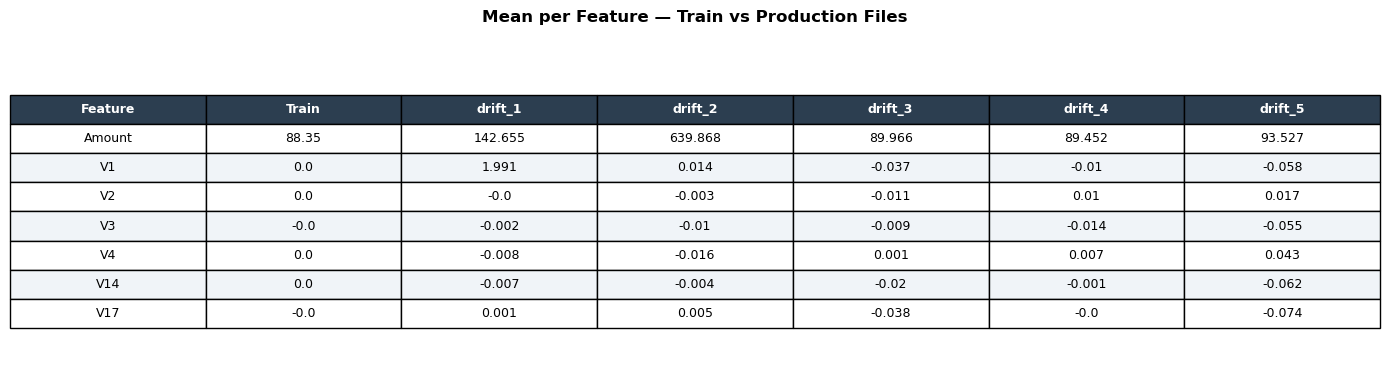

  Saved: plot1_summary_statistics.png


In [ ]:
print("\nPlot 1: Summary statistics ...")

summary_features = ["Amount", "V1", "V2", "V3", "V4", "V14", "V17"]
all_dfs = [train_df] + list(prod_dfs.values())
all_labels = ["Train"] + [os.path.splitext(os.path.basename(f))[0] for f in prod_dfs]

# Build table: rows = features, columns = datasets
table_data = [["Feature"] + all_labels]
for feat in summary_features:
    row = [feat] + [round(df[feat].mean(), 3) for df in all_dfs]
    table_data.append(row)

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")

table = ax.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

# Highlight header
for j in range(len(table_data[0])):
    table[0, j].set_facecolor("#2c3e50")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Alternate row colours
for i in range(1, len(table_data)):
    for j in range(len(table_data[0])):
        table[i, j].set_facecolor("#f0f4f8" if i % 2 == 0 else "white")

plt.title("Mean per Feature — Train vs Production Files", fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("plot1_summary_statistics.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

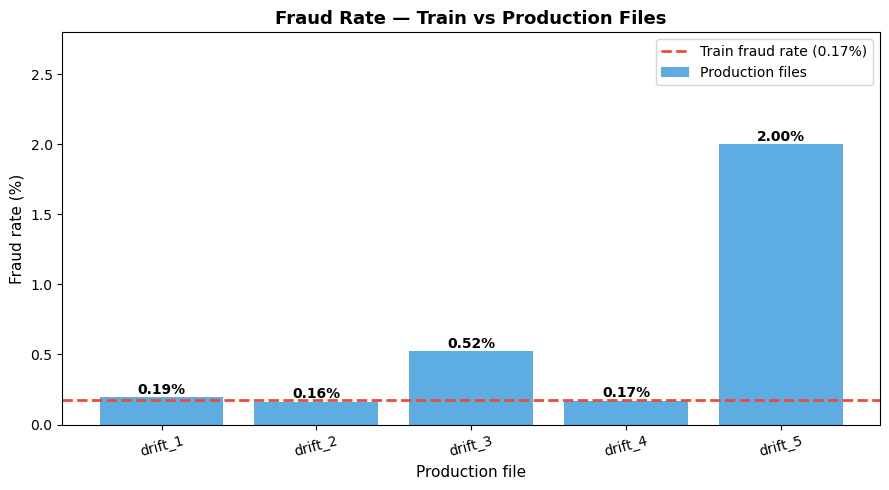

In [39]:
train_fraud_rate = train_df["Class"].mean() * 100

fraud_rates = []
for fname, df in prod_dfs.items():
    fraud_rates.append({
        "File"       : os.path.splitext(os.path.basename(fname))[0],
        "Fraud rate" : df["Class"].mean() * 100,
        "N samples"  : len(df),
    })

fraud_df = pd.DataFrame(fraud_rates)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(fraud_df["File"], fraud_df["Fraud rate"], color="#3498db", alpha=0.8, label="Production files")
ax.axhline(train_fraud_rate, color="#e74c3c", linestyle="--", linewidth=2, label=f"Train fraud rate ({train_fraud_rate:.2f}%)")

for bar, rate in zip(bars, fraud_df["Fraud rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{rate:.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xlabel("Production file", fontsize=11)
ax.set_ylabel("Fraud rate (%)", fontsize=11)
ax.set_title("Fraud Rate — Train vs Production Files", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, max(fraud_df["Fraud rate"].max(), train_fraud_rate) * 1.4)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("plot2_fraud_rate.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


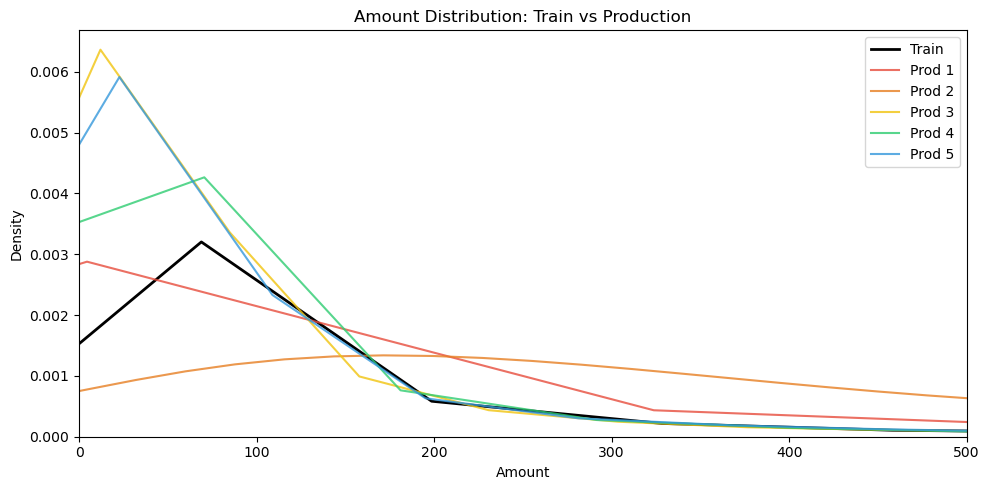

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#3498db"]

sns.kdeplot(train_df["Amount"], ax=ax, label="Train", linewidth=2, color="black")
for i, df in enumerate(prod_dfs.values()):
    sns.kdeplot(df["Amount"], ax=ax, label=f"Prod {i+1}",
                linewidth=1.5, color=colors[i], alpha=0.8)

ax.set_xlim(0, 500)   # zoom in — extreme outliers distort the plot
ax.set_title("Amount Distribution: Train vs Production")
ax.set_xlabel("Amount")
ax.legend()
plt.savefig(f"plot3_distributions.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

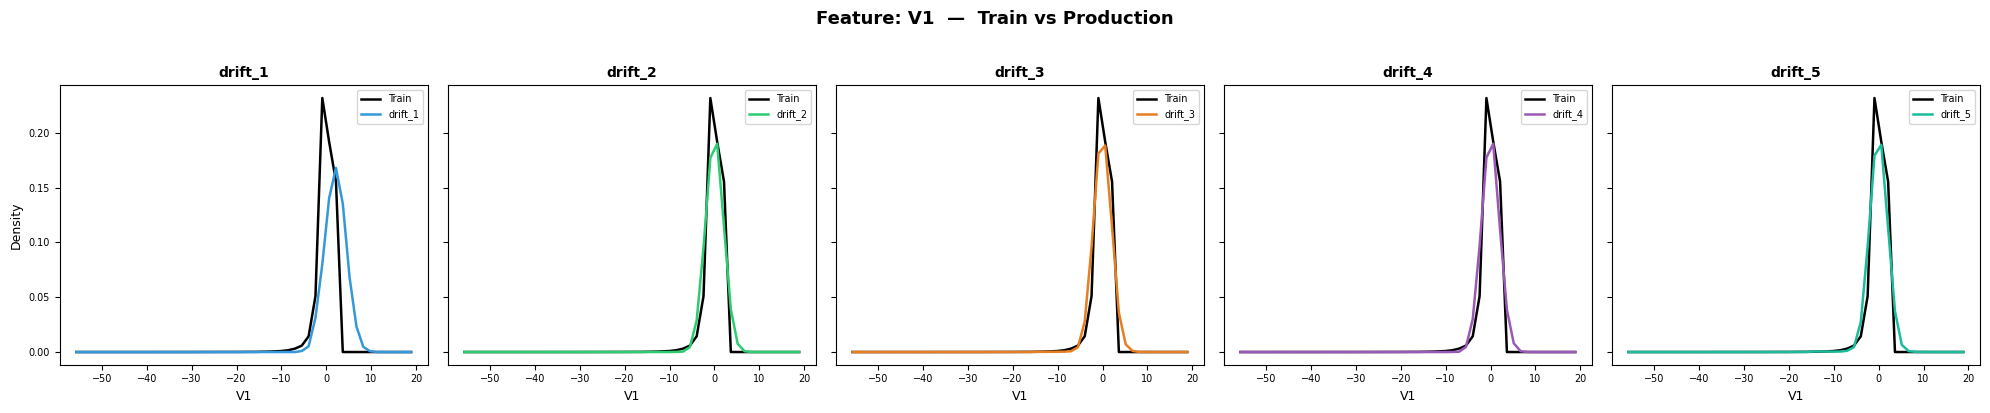

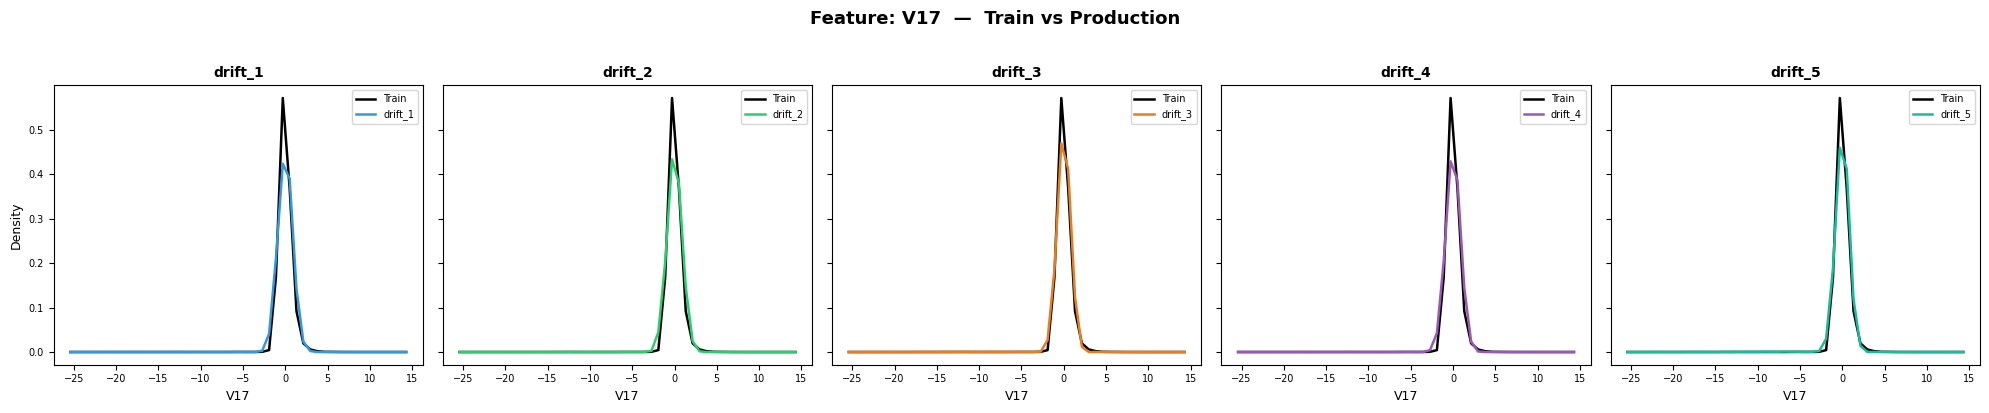

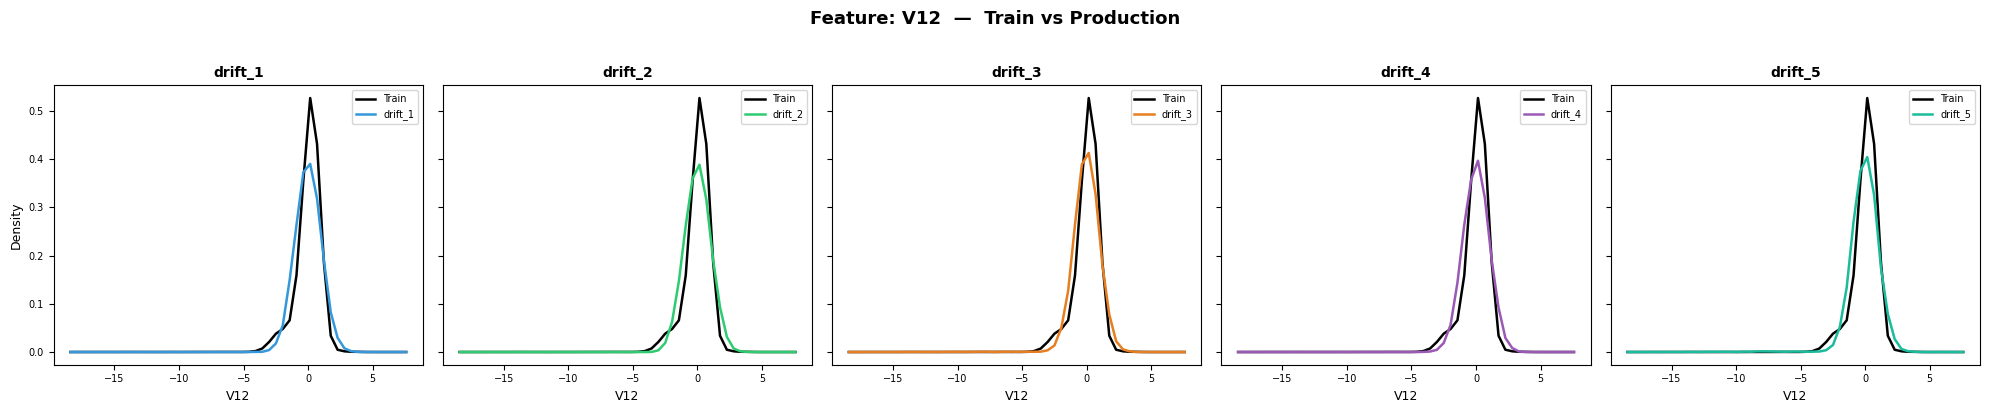

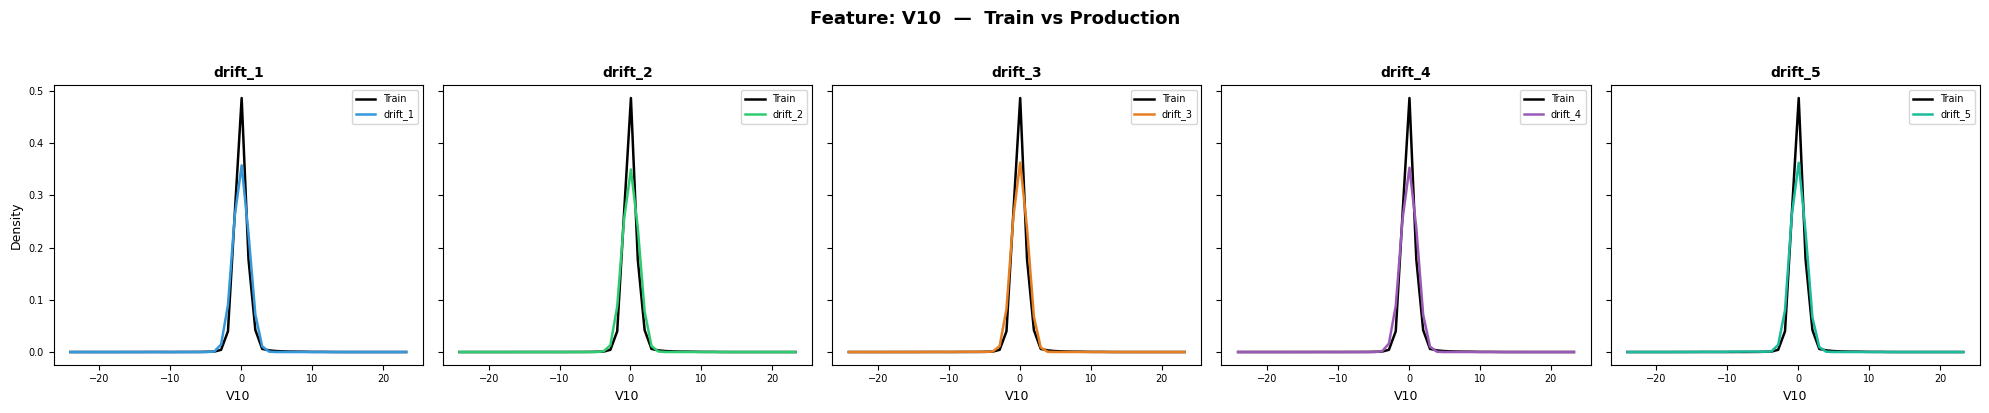

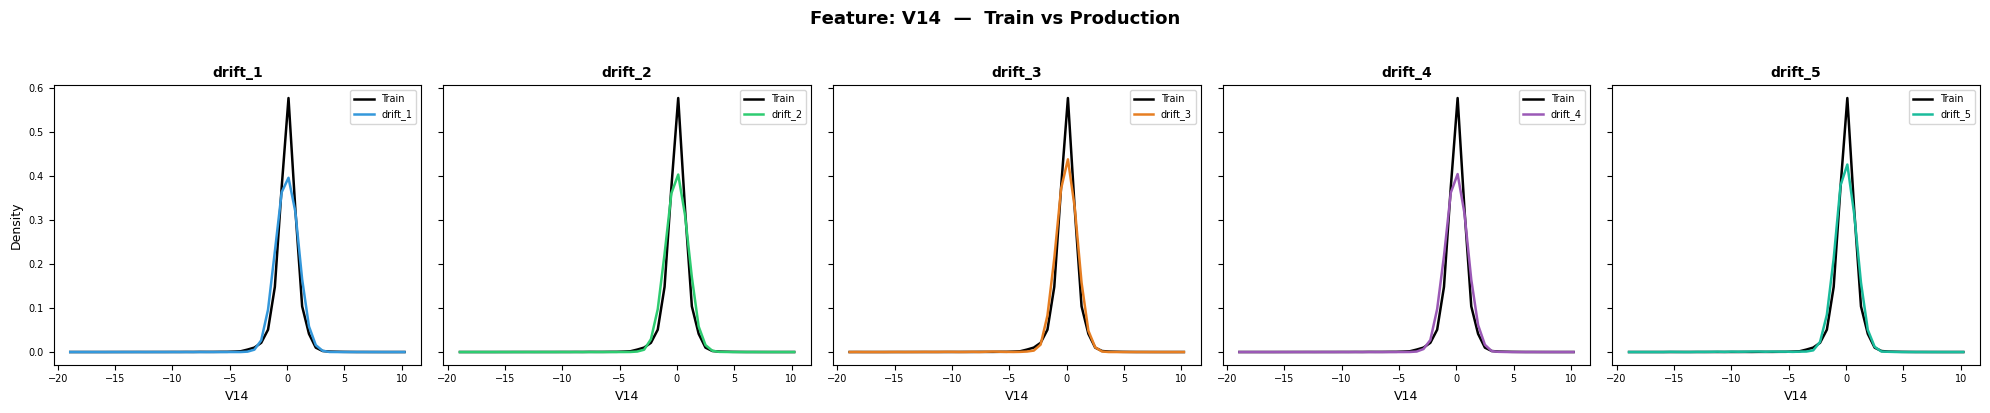

In [37]:
top_drifted = [f for f in mean_shift.index if f != "Amount"][:5]
plot_features = top_drifted[:5]

prod_colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#1abc9c"]
prod_names  = [os.path.splitext(os.path.basename(fname))[0] for fname in prod_dfs]

BINS = 50

for feat in plot_features:
    # Shared bin edges so all subplots use the same x-axis scale
    all_data = np.concatenate(
        [train_df[feat].values] + [df[feat].values for df in prod_dfs.values()]
    )
    bin_edges   = np.linspace(all_data.min(), all_data.max(), BINS + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Pre-compute train histogram once (reused in every subplot)
    train_counts, _ = np.histogram(train_df[feat], bins=bin_edges, density=True)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
    fig.suptitle(f"Feature: {feat}  —  Train vs Production",
                 fontsize=13, fontweight="bold", y=1.02)

    for i, (ax, (fname, df), color, name) in enumerate(
        zip(axes, prod_dfs.items(), prod_colors, prod_names)
    ):
        prod_counts, _ = np.histogram(df[feat], bins=bin_edges, density=True)

        ax.plot(bin_centers, train_counts,
                color="black", linewidth=1.8, label="Train")
        ax.plot(bin_centers, prod_counts,
                color=color, linewidth=1.8, label=name)

        ax.set_title(name, fontsize=10, fontweight="bold")
        ax.set_xlabel(feat, fontsize=9)
        ax.set_ylabel("Density" if i == 0 else "", fontsize=9)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.savefig(f"plot4_{feat}_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

In [28]:
print("\nPlots saved:")
print("  plot1_summary_statistics.png")
print("  plot2_fraud_rate.png")
print("  plot3_mean_shift.png")
print("  plot4_distributions.png")


Plots saved:
  plot1_summary_statistics.png
  plot2_fraud_rate.png
  plot3_mean_shift.png
  plot4_distributions.png
